# **🚗📈 Stock Price Prediction – Feature Engineering & ML Modeling**

This notebook builds a complete **data preprocessing + exploratory analysis + feature engineering + machine learning** pipeline on historical **Tesla stock data**.  
The final goal is to **predict whether the next day’s closing price will go up or down** — a binary classification problem.

---

## 🔎 **What This Code Does**

### **1️⃣ Loads & Inspects the Dataset**
- Reads the Tesla stock CSV file  
- Shows:
  - First 5 rows  
  - Shape of dataset  
  - Summary statistics (`describe`)  
  - Data types & missing values (`info`)  

---

### **2️⃣ Visualizes Stock Trends**
- Plots Tesla’s **closing price history** to observe long-term movement  
- Helps understand volatility and trend patterns  

---

### **3️⃣ Cleans and Organizes Columns**
- Removes the `Adj Close` column (duplicate of `Close`)  
- Checks for missing values  
- Ensures columns are ready for ML pipelines  

---

### **4️⃣ Exploratory Data Analysis (EDA)**
- **Distribution Plots** for Open / High / Low / Close / Volume  
- **Boxplots** to detect outliers  
- Highlights how each financial attribute behaves over time  

---

### **5️⃣ Date Parsing & Feature Extraction**
- Converts `Date` column into real datetime format  
- Extracts:
  - `day`
  - `month`
  - `year`
- Creates a new feature:
  - **`is_quarter_end`** → 1 if month ∈ {March, June, September, December}, else 0  

These help the model learn seasonal or quarterly behaviors in stock price movement.

---

### **6️⃣ Year-wise Price Analysis**
- Groups data by `year`  
- Plots bar charts for average:
  - Open  
  - High  
  - Low  
  - Close  
- Shows how Tesla price evolved over different years  

---

### **7️⃣ Feature Engineering**
Creates powerful predictive features:
- **`open-close`** → Difference between opening and closing price  
- **`low-high`** → Intraday volatility  
- **`is_quarter_end`** → Quarterly behavior  
- **`target`** →  
  - 1 if tomorrow’s close > today’s close  
  - 0 otherwise  

This transforms raw stock data into ML-friendly features.

---

### **8️⃣ Target Distribution Check**
- Visualizes class balance using a **pie chart**  
- Shows how many times Tesla closed higher or lower the next day  

---

### **9️⃣ Correlation Analysis**
- Builds a correlation matrix  
- Visualizes **only highly correlated (>0.9)** relationships  
- Helps understand multicollinearity & feature redundancy  

---

## 🤖 **10️⃣ Model Training & Evaluation**
The following ML models are trained on engineered features:

### ✔ Logistic Regression  
### ✔ Support Vector Classifier (Polynomial Kernel)  
### ✔ XGBoost Classifier  

For each model, the notebook computes:

- **Training AUC Score**  
- **Validation AUC Score**  
- **Probability-based predictions**  

This ensures a proper performance comparison across ML algorithms.

---

### **1️⃣1️⃣ Confusion Matrix for Best Model**
- Generates a clear **confusion matrix** for Logistic Regression  
- Shows correct vs incorrect up/down predictions  

---

## 🎯 **Final Outcome**

By the end of this notebook, you will have:

- Cleaned Tesla stock dataset  
- Fully visualized stock distributions, trends, and statistical patterns  
- Feature-engineered dataset based on volatility & quarterly cycles  
- Binary target indicating next-day price movement  
- Three trained ML models with AUC comparison  
- Confusion matrix for performance interpretation  



HEAD:
         Date       Open   High        Low      Close    Volume  Adj Close
0  6/29/2010  19.000000  25.00  17.540001  23.889999  18766300  23.889999
1  6/30/2010  25.790001  30.42  23.299999  23.830000  17187100  23.830000
2   7/1/2010  25.000000  25.92  20.270000  21.959999   8218800  21.959999
3   7/2/2010  23.000000  23.10  18.709999  19.200001   5139800  19.200001
4   7/6/2010  20.000000  20.00  15.830000  16.110001   6866900  16.110001

SHAPE: (1692, 7)

DESCRIBE:
               Open         High          Low        Close        Volume  \
count  1692.000000  1692.000000  1692.000000  1692.000000  1.692000e+03   
mean    132.441572   134.769698   129.996223   132.428658  4.270741e+06   
std      94.309923    95.694914    92.855227    94.313187  4.295971e+06   
min      16.139999    16.629999    14.980000    15.800000  1.185000e+05   
25%      30.000000    30.650000    29.215000    29.884999  1.194350e+06   
50%     156.334999   162.370002   153.150002   158.160004  3.180700e

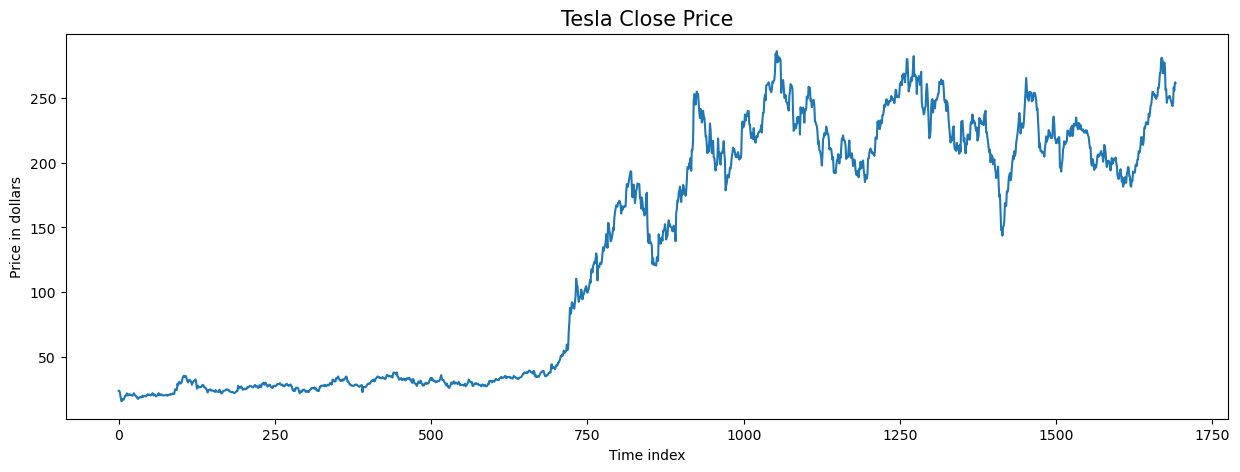


Missing values per column:
 Date      0
Open      0
High      0
Low       0
Close     0
Volume    0
dtype: int64


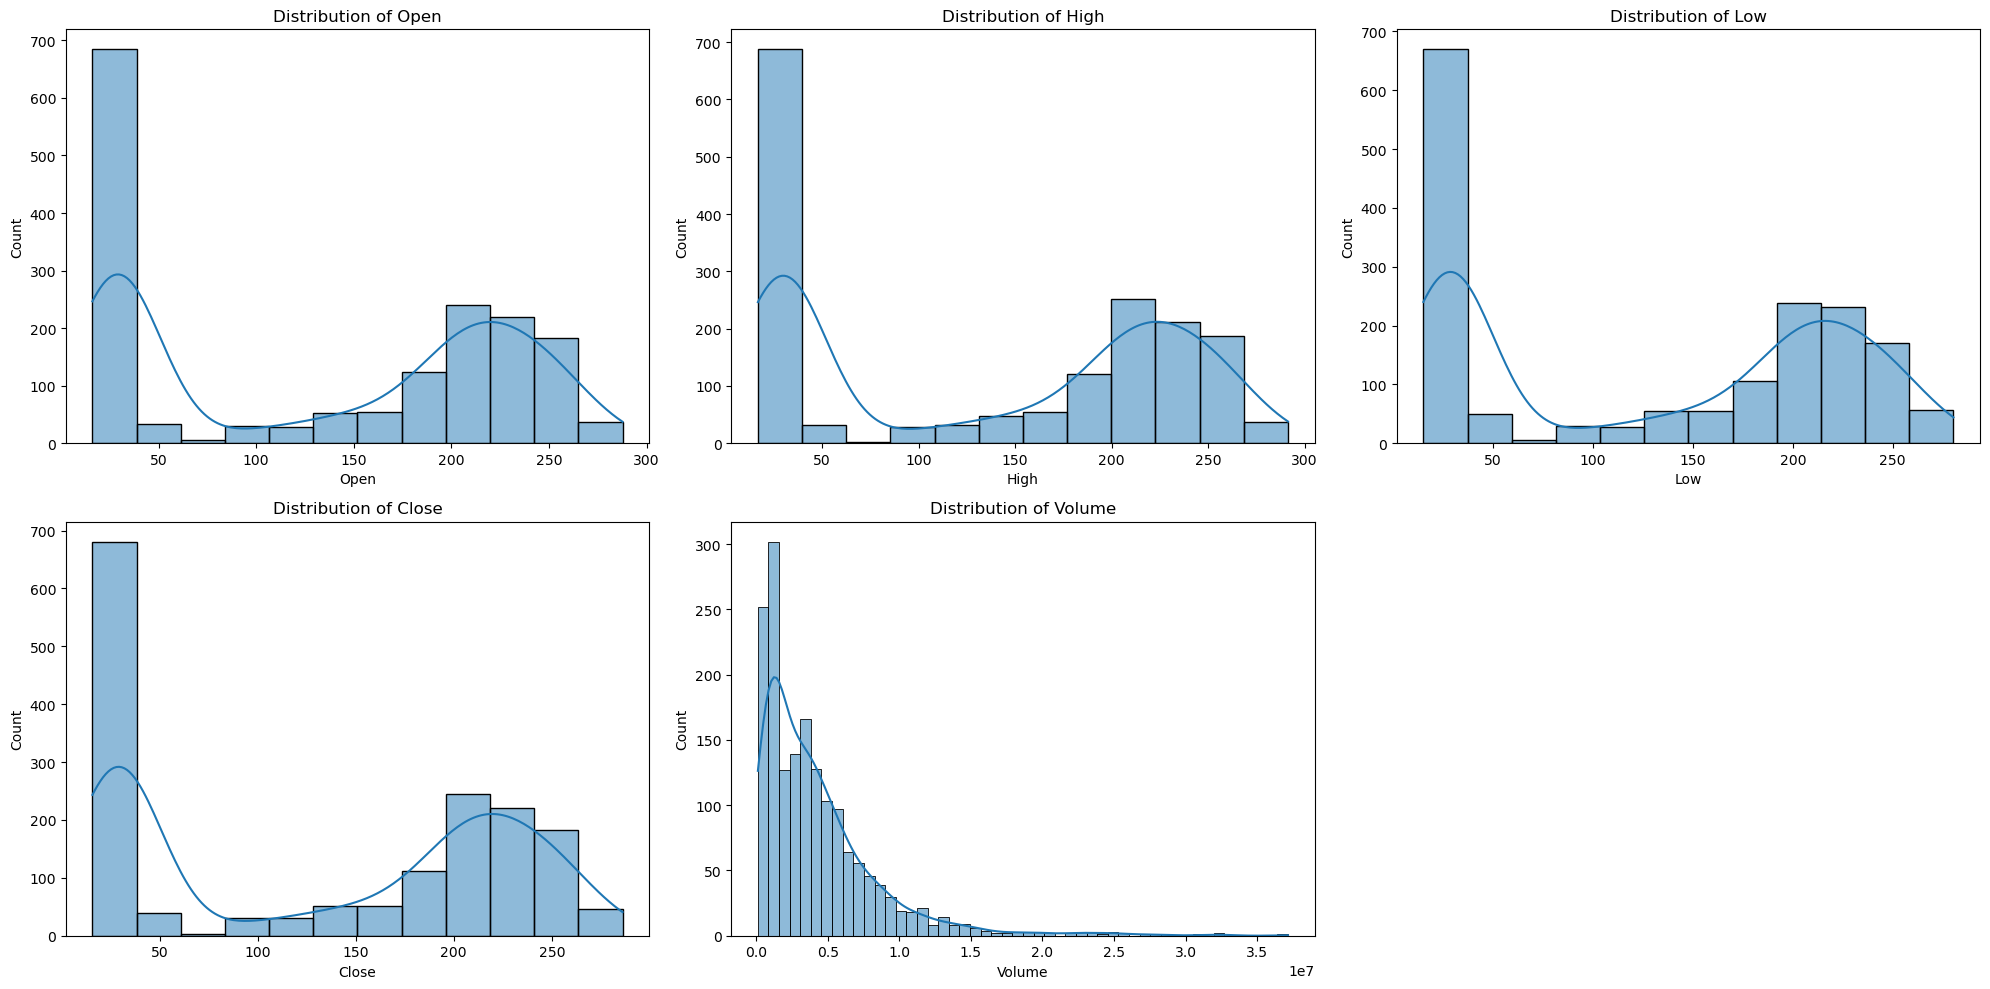

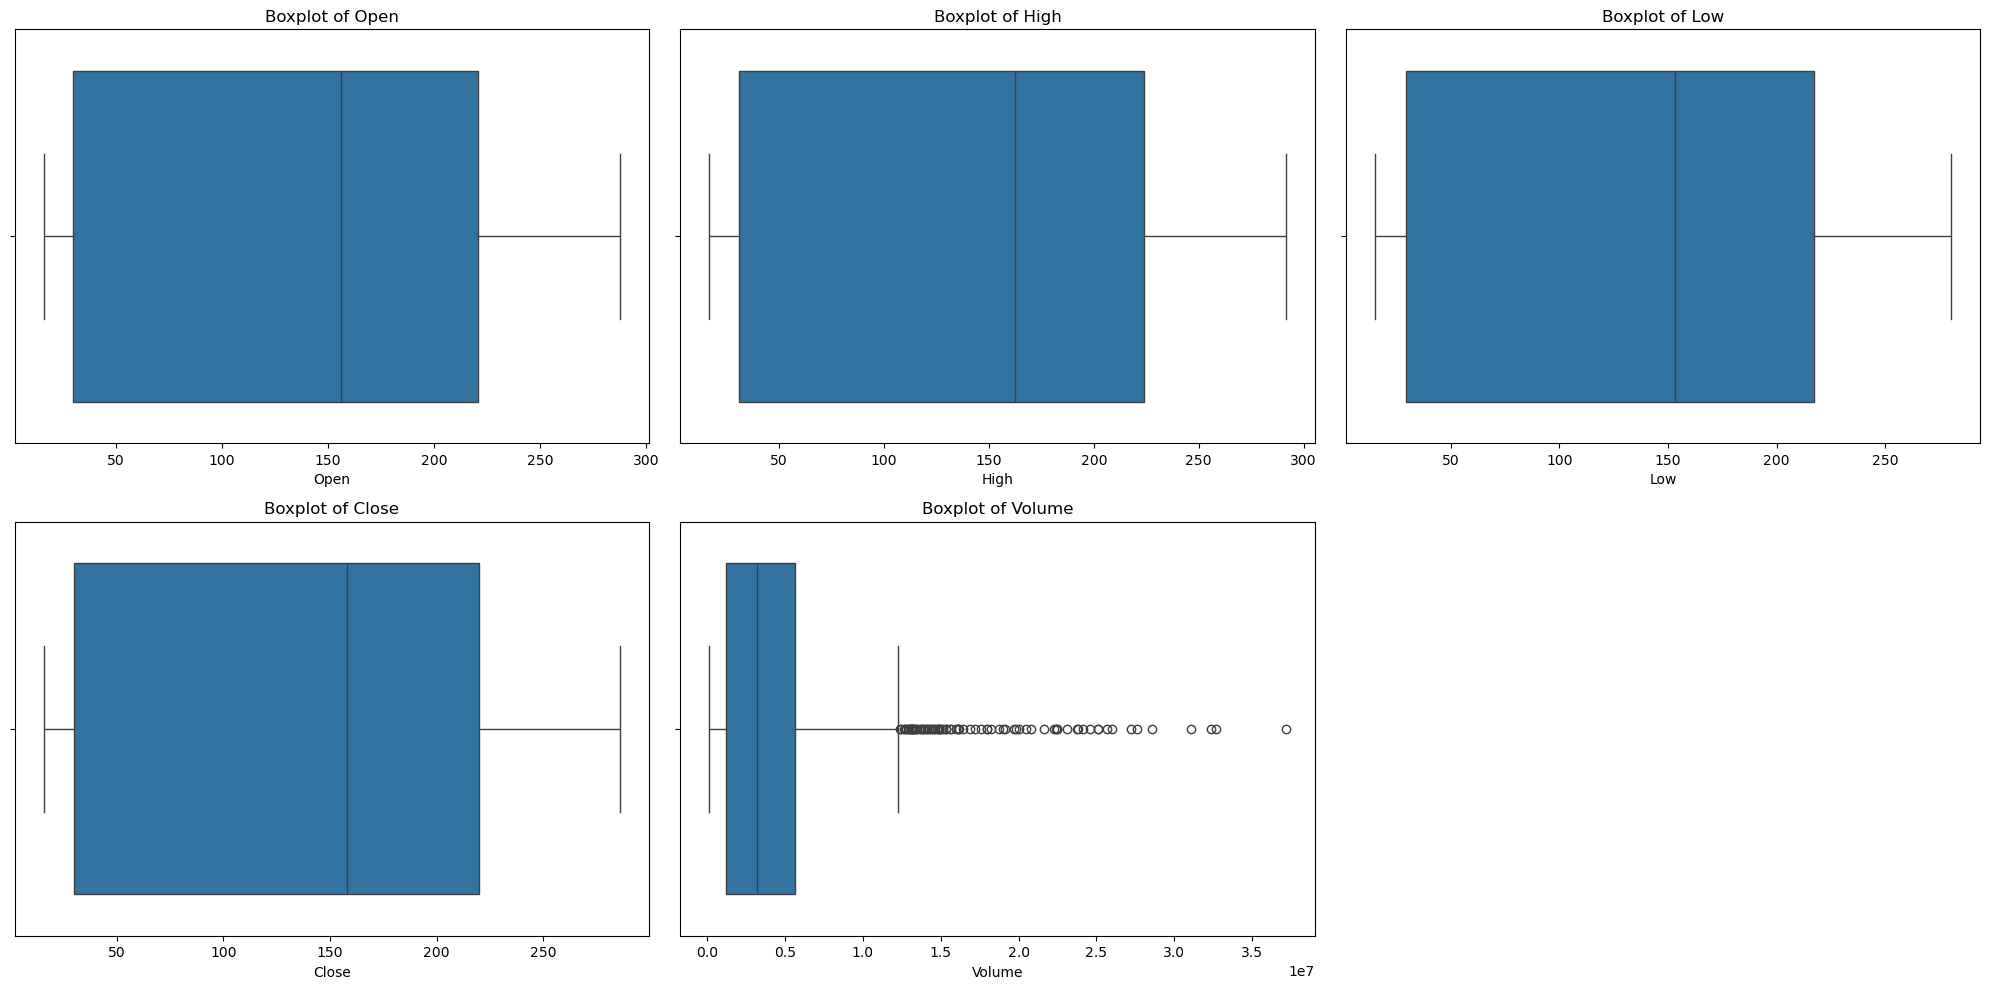


Sample with new date features:
         Date       Open   High        Low      Close    Volume  day  month  \
0 2010-06-29  19.000000  25.00  17.540001  23.889999  18766300   29      6   
1 2010-06-30  25.790001  30.42  23.299999  23.830000  17187100   30      6   
2 2010-07-01  25.000000  25.92  20.270000  21.959999   8218800    1      7   
3 2010-07-02  23.000000  23.10  18.709999  19.200001   5139800    2      7   
4 2010-07-06  20.000000  20.00  15.830000  16.110001   6866900    6      7   

   year  
0  2010  
1  2010  
2  2010  
3  2010  
4  2010  

Sample with quarter-end flag:
         Date       Open   High        Low      Close    Volume  day  month  \
0 2010-06-29  19.000000  25.00  17.540001  23.889999  18766300   29      6   
1 2010-06-30  25.790001  30.42  23.299999  23.830000  17187100   30      6   
2 2010-07-01  25.000000  25.92  20.270000  21.959999   8218800    1      7   
3 2010-07-02  23.000000  23.10  18.709999  19.200001   5139800    2      7   
4 2010-07-06  20

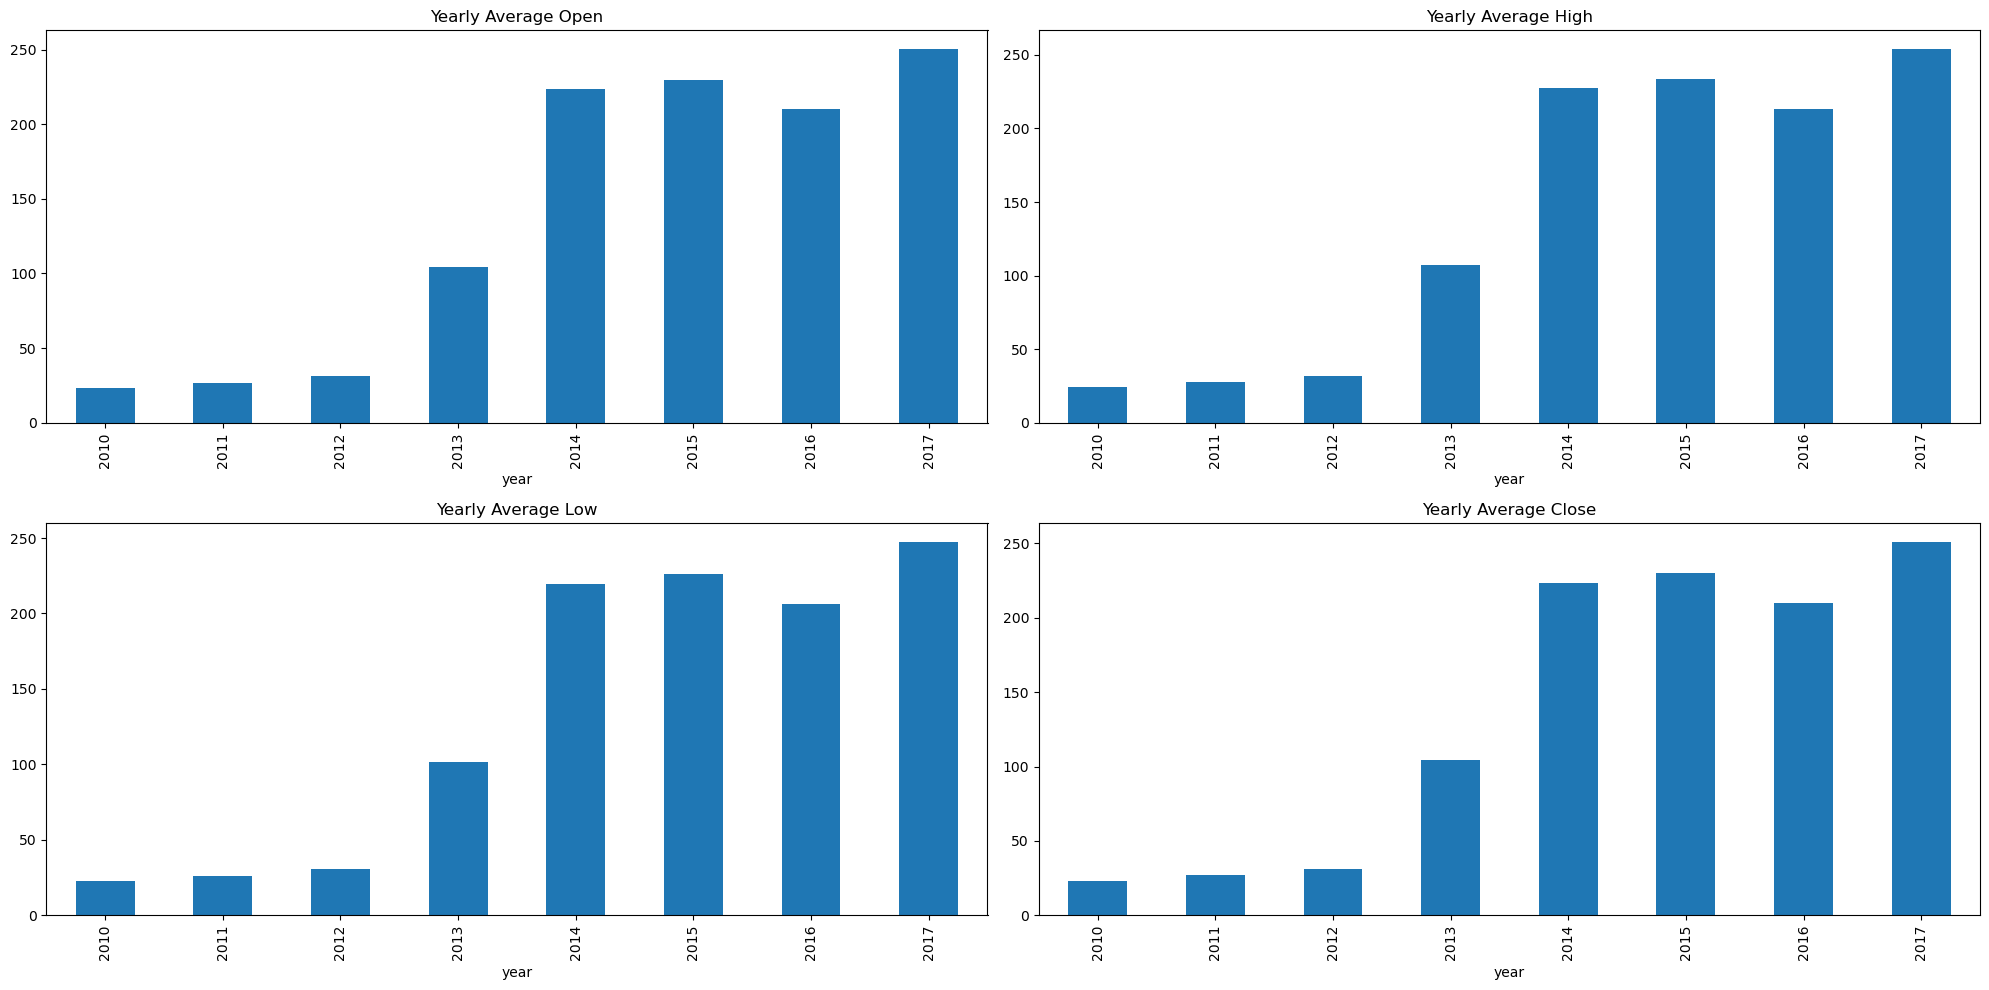


Group by is_quarter_end (mean values):

                      Open        High         Low       Close        Volume  \
is_quarter_end                                                                 
0               130.813739  133.182620  128.257229  130.797709  4.461581e+06   
1               135.679982  137.927032  133.455777  135.673269  3.891084e+06   

                      day     month         year  
is_quarter_end                                    
0               15.686501  6.141208  2013.353464  
1               15.657244  7.584806  2013.314488  


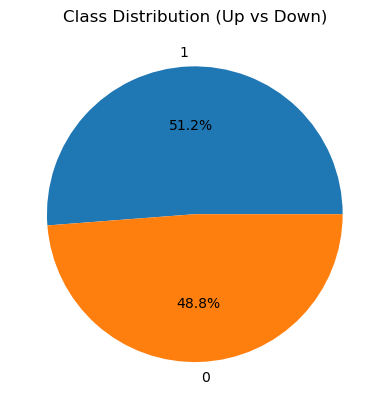

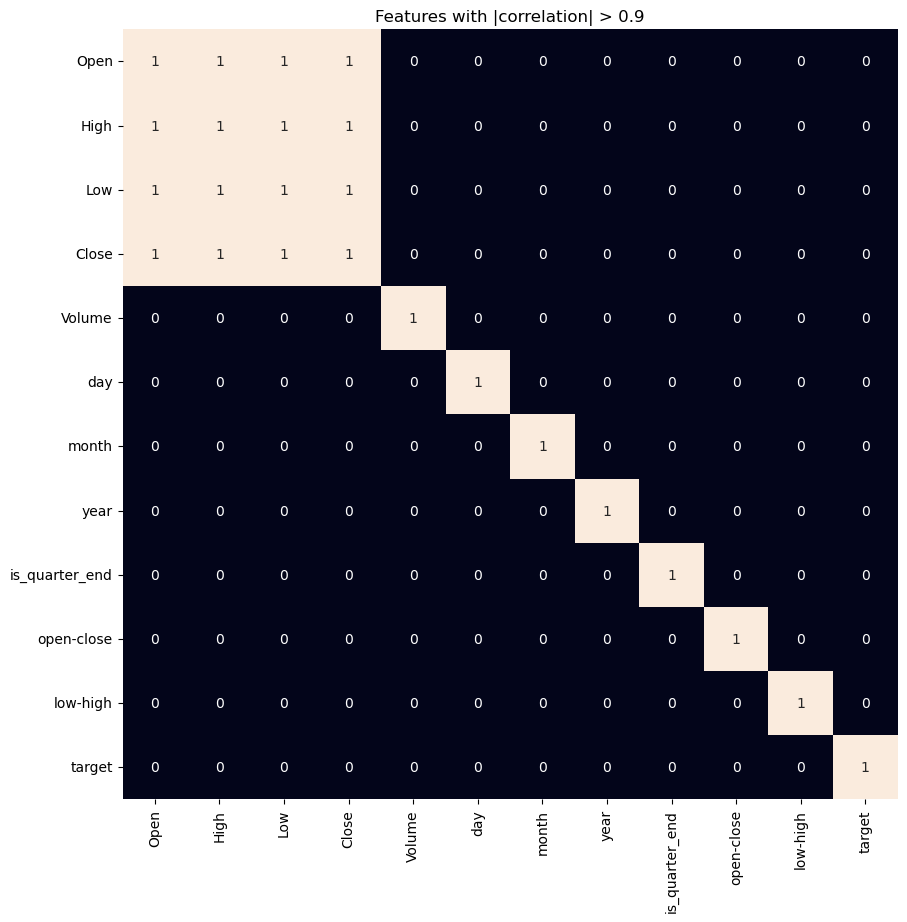


Train/Validation shapes: (1521, 3) (170, 3)

LogisticRegression(max_iter=1000) :
Training AUC: 0.5224785387306278
Validation AUC: 0.49120620412685223

SVC(kernel='poly', probability=True) :
Training AUC: 0.48278600320405246
Validation AUC: 0.518349259105387

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.9, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=3, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=200, n_jobs=None,
         

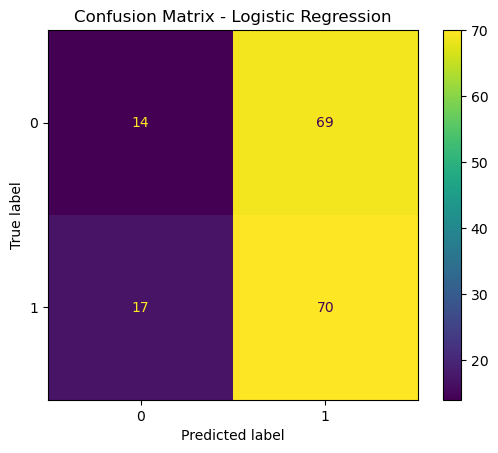

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sb

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn import metrics
from sklearn.metrics import ConfusionMatrixDisplay

import warnings
warnings.filterwarnings("ignore")

# ==========================
# 1. Load & Inspect Dataset
# ==========================

# Update the path as needed (works in Colab and local environments)
df = pd.read_csv("Tesla.csv")  # your original path was '/content/Tesla.csv'

print("\nHEAD:\n", df.head())
print("\nSHAPE:", df.shape)
print("\nDESCRIBE:\n", df.describe())
print("\nINFO:")
print(df.info())

# ==========================
# 2. Basic Visualization
# ==========================

plt.figure(figsize=(15, 5))
plt.plot(df["Close"])
plt.title("Tesla Close Price", fontsize=15)
plt.ylabel("Price in dollars")
plt.xlabel("Time index")
plt.show()

# ==========================
# 3. Clean Columns
# ==========================

# Drop 'Adj Close' only if it exists to avoid KeyError
if "Adj Close" in df.columns:
    df = df.drop(["Adj Close"], axis=1)

print("\nMissing values per column:\n", df.isnull().sum())

# ==========================
# 4. Distributions & Outliers
# ==========================

num_features = ["Open", "High", "Low", "Close", "Volume"]

plt.figure(figsize=(20, 10))
for i, col in enumerate(num_features):
    plt.subplot(2, 3, i + 1)
    sb.histplot(df[col], kde=True)
    plt.title(f"Distribution of {col}")
plt.tight_layout()
plt.show()

plt.figure(figsize=(20, 10))
for i, col in enumerate(num_features):
    plt.subplot(2, 3, i + 1)
    sb.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
plt.tight_layout()
plt.show()

# ==========================
# 5. Date Features
# ==========================

# Parse Date robustly instead of manual string split
df["Date"] = pd.to_datetime(df["Date"])

df["day"] = df["Date"].dt.day
(df["month"]) = df["Date"].dt.month
(df["year"]) = df["Date"].dt.year

print("\nSample with new date features:\n", df.head())

# Flag quarter-end months (March, June, September, December)
df["is_quarter_end"] = np.where(df["month"] % 3 == 0, 1, 0)
print("\nSample with quarter-end flag:\n", df.head())

# ==========================
# 6. Year-wise Averages
# ==========================

data_grouped = df.drop("Date", axis=1).groupby("year").mean(numeric_only=True)

plt.figure(figsize=(20, 10))
for i, col in enumerate(["Open", "High", "Low", "Close"]):
    plt.subplot(2, 2, i + 1)
    data_grouped[col].plot(kind="bar")
    plt.title(f"Yearly Average {col}")
plt.tight_layout()
plt.show()

print("\nGroup by is_quarter_end (mean values):\n")
print(df.drop("Date", axis=1).groupby("is_quarter_end").mean(numeric_only=True))

# ==========================
# 7. Feature Engineering
# ==========================

df["open-close"] = df["Open"] - df["Close"]
df["low-high"] = df["Low"] - df["High"]

# Target: 1 if next day's close is higher than today's, else 0
# shift(-1) moves next day's close up to compare with today's close
df["target"] = np.where(df["Close"].shift(-1) > df["Close"], 1, 0)

# Drop the last row where target comparison is not meaningful (optional but cleaner)
df = df[:-1]

plt.figure()
plt.pie(
    df["target"].value_counts().values,
    labels=df["target"].value_counts().index,
    autopct="%1.1f%%",
)
plt.title("Class Distribution (Up vs Down)")
plt.show()

# ==========================
# 8. Correlation Heatmap
# ==========================

plt.figure(figsize=(10, 10))

corr_matrix = df.drop("Date", axis=1).corr(numeric_only=True)

# Visualize only strong correlations (>|0.9|) as boolean mask
sb.heatmap((corr_matrix.abs() > 0.9), annot=True, cbar=False)
plt.title("Features with |correlation| > 0.9")
plt.show()

# ==========================
# 9. Train-Test Split & Scaling
# ==========================

feature_cols = ["open-close", "low-high", "is_quarter_end"]
X = df[feature_cols]
y = df["target"]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_valid, y_train, y_valid = train_test_split(
    X_scaled, y, test_size=0.1, random_state=2022, stratify=y
)

print("\nTrain/Validation shapes:", X_train.shape, X_valid.shape)

# ==========================
# 10. Model Training & Evaluation
# ==========================

models = [
    LogisticRegression(max_iter=1000),
    SVC(kernel="poly", probability=True),
    XGBClassifier(
        n_estimators=200,
        max_depth=3,
        learning_rate=0.1,
        subsample=0.9,
        colsample_bytree=0.9,
        objective="binary:logistic",
        eval_metric="logloss",
        random_state=2022,
    ),
]

for model in models:
    model.fit(X_train, y_train)
    print(f"\n{model} :")
    train_auc = metrics.roc_auc_score(y_train, model.predict_proba(X_train)[:, 1])
    valid_auc = metrics.roc_auc_score(y_valid, model.predict_proba(X_valid)[:, 1])
    print("Training AUC:", train_auc)
    print("Validation AUC:", valid_auc)

# ==========================
# 11. Confusion Matrix (for Logistic Regression)
# ==========================

best_model = models[0]  # Logistic Regression

ConfusionMatrixDisplay.from_estimator(best_model, X_valid, y_valid)
plt.title("Confusion Matrix - Logistic Regression")
plt.show()
